# N2 — LangGraph com LLMs

* Professor: Júlio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Alejandro Núñez Arroyo <a href="mailto:r299215@dac.unicamp.br">(r299215@dac.unicamp.br)</a>
* Material base: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a>

Este notebook coloca chamadas de modelo dentro dos nós de um grafo do LangGraph. O estado passa a guardar as mensagens da conversa, o prompt de sistema passa a ser montado pelo nó, e a saída do modelo passa a alimentar as decisões de rota.

As seções vão do menor caso executável, um grafo de um nó, até um ciclo de geração, avaliação e revisão. Em todos eles a divisão de trabalho é a mesma: o modelo produz texto ou um objeto validado, e o grafo decide qual nó roda em seguida e quando a execução termina.

## 0.1 Pré-requisitos

Este notebook pressupõe os seguintes conhecimentos:

- Python: funções, dicionários, f-strings e anotações de tipo;
- declaração de estado com `TypedDict` e construção de grafos com `StateGraph`, `add_node` e `add_edge`;
- roteamento com `add_conditional_edges` e acúmulo de valores por reducer;
- papéis das mensagens de uma conversa: sistema, usuário e assistente.

## 0.2 Objetivos da aula

Objetivos deste notebook:

1. Colocar uma chamada de modelo dentro de um nó e devolver a resposta como atualização do estado.
2. Acumular o histórico da conversa no campo `messages` com o reducer `add_messages`.
3. Montar a lista de mensagens de uma chamada a partir de um prompt de sistema fixo.
4. Acompanhar a execução do grafo com `stream` nos modos `updates` e `messages`.
5. Obter do modelo um objeto validado com `with_structured_output` e um esquema Pydantic.
6. Rotear a execução pela categoria classificada, com um nó especializado por categoria.
7. Construir um ciclo de geração, avaliação e revisão com critério de parada explícito.
8. Trocar o provedor do modelo sem alterar os nós do grafo.

## 0.3 Mapa do notebook

Conteúdo deste notebook:

1. Papéis do LLM no grafo.
2. Chatbot mínimo.
3. Acúmulo de mensagens.
4. Prompt de sistema no nó.
5. Observação da execução.
6. Classificação de intenção.
7. Roteamento por intenção.
8. Ciclo de revisão.
9. Exercícios de fixação.
10. Resumo da aula.
11. Referências.

## 0.4 Contexto usado nos exemplos

Os exemplos deste notebook montam um tutor do curso de agentes com LLMs. Os alunos Julio e Renan enviam dúvidas sobre LangGraph, e o grafo produz a resposta. Conforme o notebook avança, o mesmo tutor ganha histórico de conversa, prompt de sistema, classificação do pedido, nós especializados por tipo de pedido e um ciclo de revisão da própria resposta. Cada seção declara o próprio estado e o próprio grafo.

## 0.5 Preparação do ambiente

O notebook usa o modelo `gpt-oss:120b`, executado na infraestrutura do Ollama e acessado pela API em `https://ollama.com`. A seção 0.6 registra também a configuração do Gemini, para o caso de a execução ser feita pela API do Google.

As bibliotecas são `langgraph` (grafo, reducers e stream), `langchain-ollama` e `langchain-google-genai` (clientes dos dois provedores), `pydantic` (esquemas das seções 6 e 8) e `python-dotenv` (leitura da chave). O `langchain-google-genai` só é carregado quando a constante `PROVEDOR` da seção 0.6 tem o valor `"gemini"`.

As seções 6 e 8 pedem ao modelo um objeto validado em vez de texto. Isso depende de tool calling, o mecanismo pelo qual o modelo preenche os argumentos de uma função declarada no pedido.

O acesso ao modelo hospedado exige uma chave de API. Os passos para obtê-la:

1. Criar uma conta em [ollama.com](https://ollama.com) e entrar nela.
2. Abrir [ollama.com/settings/keys](https://ollama.com/settings/keys) e gerar uma chave nova.
3. Copiar o valor exibido, que aparece uma única vez.
4. Guardar o valor na variável de ambiente `OLLAMA_API_KEY`.

Há três formas de cumprir o passo 4. Em uma máquina local, escreva a linha `OLLAMA_API_KEY=...` em um arquivo `.env` ao lado do notebook, que já está no `.gitignore`, e deixe o `load_dotenv()` da seção 0.6 carregá-la. A segunda forma é exportar a variável no ambiente antes de abrir o notebook. A terceira é a célula comentada abaixo, para o Google Colab. Não escreva a chave no código versionado.

In [1]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
# %pip install -U langgraph langchain-ollama langchain-google-genai pydantic python-dotenv

A célula a seguir cobre o caso do Google Colab, onde não há arquivo `.env`. Descomente as três linhas, cole a chave entre as aspas e execute a célula. Torne a comentá-las antes de salvar o notebook, para que a chave não seja gravada no arquivo.

In [2]:
# # Descomente no Google Colab, onde não há arquivo .env.
# import os
# os.environ["OLLAMA_API_KEY"] = ""
# os.environ["GOOGLE_API_KEY"] = ""

Agora importamos os elementos que serão usados ao longo da aula.

In [3]:
import os

from dotenv import load_dotenv

from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage
from langchain_core.runnables import Runnable
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama

from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages

from pydantic import BaseModel, Field
from typing import Annotated, Literal, TypedDict

Glossário dos imports:

- `os` e `load_dotenv`: leitura das chaves de API a partir do ambiente ou do arquivo `.env`;
- `AnyMessage`: tipo comum às mensagens de uma conversa, usado na anotação do estado;
- `HumanMessage` e `SystemMessage`: o pedido do aluno e a instrução fixa enviada ao modelo;
- `Runnable`: tipo do objeto devolvido por `with_structured_output`, usado na assinatura de um auxiliar da seção 6;
- `ChatOllama` e `ChatGoogleGenerativeAI`: clientes dos dois provedores configurados na seção 0.6;
- `StateGraph`, `START` e `END`: construtor do grafo e os nós virtuais de entrada e saída;
- `add_messages`: reducer que concatena mensagens no estado em vez de substituí-las;
- `BaseModel` e `Field`: esquema e descrição dos campos pedidos ao modelo nas seções 6 e 8;
- `TypedDict`, `Annotated` e `Literal`: campos do estado, associação do reducer e conjunto fechado de valores.

A função auxiliar abaixo exibe o desenho de um grafo compilado. Ela é usada ao final das células de exemplo, depois da execução.

In [4]:
from langgraph.graph.state import CompiledStateGraph
from IPython.display import Image, display


def display_graph(graph: CompiledStateGraph) -> None:
    """Renderiza o grafo compilado como imagem PNG."""
    display(Image(graph.get_graph().draw_mermaid_png()))

## 0.6 Escolhendo um provedor de LLM

O notebook instancia o modelo por uma função única, `criar_modelo`, e os nós das seções seguintes chamam o objeto devolvido por ela. A constante `PROVEDOR` seleciona qual cliente é construído.

Os dois provedores diferem em três pontos, e a função concentra os três:

| Ponto | Ollama | Gemini |
|---|---|---|
| Classe | `ChatOllama` | `ChatGoogleGenerativeAI` |
| Conexão | `base_url` em `https://ollama.com` e cabeçalho `Authorization` entregue por `client_kwargs` | chave entregue em `api_key` |
| Limite de tokens da resposta | `num_predict` | `max_output_tokens` |
| Amostragem | `temperature` | fixa; a família Gemini 3.x não aceita `temperature`, `top_p` nem `top_k` |
| Raciocínio | `reasoning` | `thinking_level`, com os valores `minimal`, `low`, `medium` e `high` |
| Campo `content` da resposta | uma string | uma lista de blocos, conforme a subseção 2.1 |

As saídas gravadas neste arquivo vêm do Ollama. Para executar pelo Gemini, gere uma chave em [https://aistudio.google.com/api-keys](https://aistudio.google.com/api-keys), guarde-a na variável `GOOGLE_API_KEY` e troque o valor de `PROVEDOR`. O restante do notebook não muda.

O parâmetro `reasoning=False` retira o texto de raciocínio do `gpt-oss` do campo da resposta. Os tokens de raciocínio continuam sendo gerados e continuam contando no orçamento de `num_predict`. Quando o orçamento acaba antes da resposta visível, a chamada volta com `done_reason` igual a `length` e sem texto. O valor 1200 de `LIMITE_RESPOSTA` deixa margem para as duas partes.

No Gemini o controle equivalente é o `thinking_level`, que aceita `minimal`, `low`, `medium` e `high` [https://ai.google.dev/gemini-api/docs/thinking#thinking-levels](https://ai.google.dev/gemini-api/docs/thinking#thinking-levels). Os tokens de raciocínio contam no orçamento de `max_output_tokens` e são reportados em `usage_metadata["output_token_details"]["reasoning"]`. A família Gemini 3.x deixou de aceitar `temperature`, `top_p` e `top_k` na configuração de geração, conforme a documentação do provedor listada na seção 11.

In [5]:
load_dotenv()

PROVEDOR = "ollama"  # troque para "gemini" depois de definir GOOGLE_API_KEY

MODELO_OLLAMA = "gpt-oss:120b"           # servido por https://ollama.com
MODELO_GEMINI = "gemini-3.5-flash-lite"  # servido pela API do Google AI Studio

URL_OLLAMA = "https://ollama.com"
TEMPERATURA = 0
LIMITE_RESPOSTA = 1200  # tokens gerados por chamada


def criar_modelo(provedor: str = PROVEDOR):
    """Instancia o cliente do provedor escolhido com o mesmo orçamento de geração."""
    if provedor == "ollama":
        chave = os.environ.get("OLLAMA_API_KEY")
        if not chave:
            raise RuntimeError(
                "OLLAMA_API_KEY não encontrada. Gere uma chave em "
                "https://ollama.com/settings/keys e defina a variável no arquivo .env, "
                "no ambiente do sistema ou na célula da seção 0.5."
            )

        return ChatOllama(
            model=MODELO_OLLAMA,
            base_url=URL_OLLAMA,
            client_kwargs={"headers": {"Authorization": f"Bearer {chave}"}},
            reasoning=False,
            temperature=TEMPERATURA,
            num_predict=LIMITE_RESPOSTA,
        )

    if provedor == "gemini":
        chave = os.environ.get("GOOGLE_API_KEY")
        if not chave:
            raise RuntimeError(
                "GOOGLE_API_KEY não encontrada. Gere uma chave em "
                "https://aistudio.google.com/apikey e defina a variável no arquivo .env "
                "ou no ambiente do sistema."
            )

        # A família Gemini 3.x não aceita temperature, top_p nem top_k.
        # O nível de raciocínio ocupa o lugar do reasoning do Ollama.
        return ChatGoogleGenerativeAI(
            model=MODELO_GEMINI,
            api_key=chave,
            max_output_tokens=LIMITE_RESPOSTA,
            thinking_level="low",
        )

    raise RuntimeError(f"Provedor não reconhecido: {provedor}. Use 'ollama' ou 'gemini'.")


modelo = criar_modelo()

print(PROVEDOR, "|", type(modelo).__name__)

ollama | ChatOllama


---

# 1. Papéis do LLM no grafo

Uma chamada de modelo é uma função: recebe uma lista de mensagens e devolve uma mensagem. Dentro de um nó, ela produz a atualização de estado que o LangGraph combina com o estado corrente. O que muda de um exemplo para outro é o campo que a chamada preenche e o uso que o grafo faz desse campo.

Três usos aparecem neste notebook:

- **resposta**: o texto gerado é o resultado da aplicação e vai para o campo de saída;
- **classificação**: o modelo devolve um valor de um conjunto fechado, e uma aresta condicional lê esse valor para escolher o próximo nó;
- **avaliação**: o modelo julga um texto produzido antes e devolve um veredito, que decide entre repetir o trecho e terminar.

Nos três, a estrutura da aplicação está declarada no grafo: quais nós existem, o que cada um lê e escreve, e sob que condição a execução passa de um para outro. O fluxo montado na seção 7 tem esta forma:

```text
START
  ↓
classificar_intencao
  ↓
rotear_por_intencao
  ├── responder_conceito
  ├── gerar_codigo
  ├── criar_exercicio
  └── responder_outro
  ↓
END
```

---

# 2. Chatbot mínimo

O menor grafo com modelo tem um nó. O estado guarda a lista de mensagens da conversa, o nó chama o modelo com essa lista e devolve a resposta como atualização do campo `messages`.

O campo é anotado com o reducer `add_messages`, que concatena a lista existente com a lista devolvida pelo nó. Sem o reducer, a atualização trocaria o histórico inteiro pela última mensagem.

Fluxo:

```text
START → responder → END
```

Um grafo dirigido é uma estrutura composta por vértices (nós) conectados por arestas que possuem orientação, ou seja, cada aresta vai de um vértice de origem para um vértice de destino. Essa direção permite representar relações assimétricas, como “A segue B” ou “caminho de X para Y”, diferentemente dos grafos não dirigidos, onde as conexões são bidirecionais.
Mensagens no estado: 2


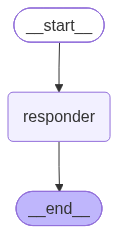

In [6]:
class EstadoChat(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


def responder(state: EstadoChat) -> dict:
    """Chama o modelo com o histórico e devolve a resposta como mensagem nova."""
    resposta = modelo.invoke(state["messages"])

    return {"messages": [resposta]}


builder = StateGraph(EstadoChat)

builder.add_node("responder", responder)

builder.add_edge(START, "responder")
builder.add_edge("responder", END)

graph = builder.compile()

resultado = graph.invoke(
    {"messages": [HumanMessage("Explique em duas frases o que é um grafo dirigido.")]}
)

print(resultado["messages"][-1].text)
print("Mensagens no estado:", len(resultado["messages"]))

display_graph(graph)

## 2.1 Leitura da execução

1. `EstadoChat` declara um campo, `messages`, com o reducer `add_messages`.
2. `invoke` recebe o estado inicial com uma `HumanMessage`.
3. O nó `responder` passa a lista inteira para `modelo.invoke`.
4. O modelo devolve uma `AIMessage`, que o nó embrulha em uma lista de um elemento.
5. O reducer concatena essa lista ao histórico.

O estado final tem duas mensagens. O nó não repetiu a pergunta na atualização que devolveu, e ela continua no estado porque o reducer soma em vez de substituir.

O texto da resposta é lido pelo atributo `text`, e não por `content`. O formato de `content` muda com o provedor: o Ollama devolve uma string, e o Gemini devolve uma lista de blocos. O atributo `text` devolve a string nos dois casos, e é o usado nas células deste notebook.

---

# 3. Acúmulo de mensagens

O modelo não guarda a conversa entre chamadas. O histórico é reenviado a cada turno, e o estado do grafo é que o carrega de uma execução para a outra. Esta seção executa dois turnos com o grafo da seção 2: o segundo recebe as mensagens devolvidas pelo primeiro mais uma pergunta cuja resposta depende do turno anterior.

Fluxo:

```text
turno 1: [pergunta]                          → [pergunta, resposta]
turno 2: [pergunta, resposta, nova pergunta] → [pergunta, resposta, nova pergunta, nova resposta]
```

In [7]:
turno_1 = graph.invoke(
    {"messages": [HumanMessage("Cite três componentes de um grafo do LangGraph, um por linha, sem explicar.")]}
)

turno_2 = graph.invoke(
    {"messages": turno_1["messages"] + [HumanMessage("Qual foi o segundo item da lista anterior?")]}
)

for mensagem in turno_2["messages"]:
    print(f"[{type(mensagem).__name__}]", mensagem.text)
    print("-" * 60)

[HumanMessage] Cite três componentes de um grafo do LangGraph, um por linha, sem explicar.
------------------------------------------------------------
[AIMessage] Node  
Edge  
State
------------------------------------------------------------
[HumanMessage] Qual foi o segundo item da lista anterior?
------------------------------------------------------------
[AIMessage] Edge
------------------------------------------------------------


## 3.1 Leitura da execução

1. O turno 1 roda o grafo da seção 2 e devolve duas mensagens.
2. `turno_1["messages"]` é concatenado à pergunta nova e vira a entrada do turno 2.
3. O grafo do turno 2 recebe três mensagens e devolve quatro.

A pergunta do segundo turno não repete a lista do primeiro. A resposta depende do que está no histórico, e o histórico chegou ao modelo porque o estado o transportou de uma execução para a outra.

---

# 4. Prompt de sistema no nó

A lista enviada ao modelo não precisa ser o conteúdo do estado. O nó monta essa lista, e o prompt de sistema entra na montagem sem ser gravado no histórico. O campo `messages` continua guardando apenas a conversa entre aluno e tutor.

Fluxo:

```text
state["messages"]  →  [SystemMessage(PROMPT_TUTOR), *state["messages"]]  →  modelo
```

In [8]:
PROMPT_TUTOR = """Atue como tutor do curso de agentes com LLMs.
O aluno já conhece LangChain e programa em Python.
Responda em no máximo quatro frases, nomeando o mecanismo do LangGraph envolvido.
Não repita a pergunta antes de responder."""


def tutor(state: EstadoChat) -> dict:
    """Antepõe o prompt de sistema ao histórico antes de chamar o modelo."""
    mensagens = [SystemMessage(PROMPT_TUTOR), *state["messages"]]
    resposta = modelo.invoke(mensagens)

    return {"messages": [resposta]}


builder = StateGraph(EstadoChat)

builder.add_node("tutor", tutor)

builder.add_edge(START, "tutor")
builder.add_edge("tutor", END)

graph = builder.compile()

resultado = graph.invoke(
    {"messages": [HumanMessage("Qual é a diferença entre nó e aresta?")]}
)

print(resultado["messages"][-1].text)
print("Mensagens no estado:", len(resultado["messages"]))

Um **nó** representa um ponto de execução – tipicamente uma função, agente ou ferramenta que processa o estado.  
Uma **aresta** define a transição entre nós, indicando para qual nó o fluxo deve seguir com base no estado ou em condições.  
No LangGraph isso é modelado pelo mecanismo **StateGraph**, onde usamos `.add_node()` para criar nós e `.add_edge()` para conectar‑os.
Mensagens no estado: 2


## 4.1 Leitura da execução

1. `PROMPT_TUTOR` fica em uma constante, fora do estado.
2. O nó monta a lista com o prompt na frente e o histórico em seguida.
3. O nó devolve apenas a resposta do modelo.

O estado final tem duas mensagens. A `SystemMessage` foi enviada ao modelo e não entrou no histórico, porque não faz parte do valor devolvido pelo nó. A cada passagem pelo nó ela é montada de novo, com o mesmo texto.

**Atenção:** o grafo não verifica o conteúdo do texto gerado. Nas saídas gravadas neste notebook, o modelo atribui ao LangGraph nomes que não existem na API, como `StateReducer` e `state patch`. O assunto das seções é o percurso do estado pelo grafo, e as respostas do modelo são lidas como dados, não como documentação do framework.

---

# 5. Observação da execução

O método `invoke` devolve o estado final. O método `stream` devolve os passos intermediários, e o parâmetro `stream_mode` define o que cada evento carrega:

| Modo | Um evento por | Conteúdo do evento |
|---|---|---|
| `updates` | nó executado | o dicionário devolvido pelo nó |
| `values` | passo do grafo | o estado inteiro depois do passo |
| `messages` | pedaço gerado | o texto parcial e o nó que o produziu |

A célula abaixo usa o modo `updates` sobre o grafo do tutor.

In [9]:
entrada = {"messages": [HumanMessage("Para que serve um reducer no estado?")]}

for evento in graph.stream(entrada, stream_mode="updates"):
    for no, atualizacao in evento.items():
        print("nó:", no, "| campos:", list(atualizacao))
        print(atualizacao["messages"][-1].text)

nó: tutor | campos: ['messages']
Um **reducer** serve para combinar/agregar os resultados parciais produzidos por diferentes nós (ou ramos) em um único estado compartilhado. Ele recebe as saídas individuais, aplica a lógica de mesclagem definida (por exemplo, sobrescrita, concatenação ou soma) e atualiza o estado de forma determinística. No LangGraph, esse mecanismo é chamado **Reducer** (ou `StateReducer`) dentro do `StateGraph`. Assim, o reducer garante que o estado final reflita a contribuição de todas as partes do fluxo.


## 5.1 Leitura da execução

O grafo tem um nó, e o laço imprimiu um evento. A chave do dicionário é o nome registrado em `add_node`, e o valor é a atualização que o nó devolveu, com o campo `messages` e nada mais. Em um grafo com vários nós, o modo `updates` emite um evento por nó executado, na ordem da execução, e o caminho percorrido aparece na saída sem instrumentar as funções.

## 5.2 Fluxo de tokens

O modo `messages` emite um evento a cada pedaço gerado, antes de o nó terminar. Cada evento é um par: a mensagem parcial e um dicionário de metadados, cuja chave `langgraph_node` identifica o nó de origem. Parte dos pedaços chega sem texto, porque o modelo também emite os tokens de raciocínio que a seção 0.6 retirou do campo. A célula abaixo guarda apenas os pedaços com texto e reporta a contagem junto com o trecho inicial.

In [10]:
pedacos = []

for pedaco, metadados in graph.stream(entrada, stream_mode="messages"):
    if pedaco.text:
        pedacos.append((metadados["langgraph_node"], pedaco.text))

print("Pedaços com texto:", len(pedacos))
print("Nó de origem:", pedacos[0][0])
print("Trecho inicial:", "".join(conteudo for _, conteudo in pedacos[:25]))

Pedaços com texto: 45
Nó de origem: tutor
Trecho inicial: Um reducer combina atualizações parciais de estado produzidas por diferentes nós ou ramificações, garantindo que o estado final seja uma única estrutura coerente. Ele resolve conflitos e agrega resultados antes que o próximo passo da cadeia seja


## 5.3 Origem dos pedaços

Cada pedaço corresponde a um trecho de texto gerado, e a contagem cresce com o tamanho da resposta. O tamanho de cada pedaço é do provedor: a mesma resposta que chegou em 105 pedaços pelo Ollama chegou em 5 pelo Gemini. Os metadados trazem o nó de origem em cada evento, o que separa os textos quando dois nós geram em sequência. A exibição incremental de uma resposta em uma interface é montada a partir desses eventos.

---

# 6. Classificação de intenção

Uma aresta condicional lê um campo do estado e devolve o nome do próximo nó. Para o modelo alimentar essa decisão, o valor precisa vir de um conjunto conhecido, e não de texto livre.

O método `with_structured_output` recebe um esquema e devolve um objeto validado por ele. O esquema abaixo tem dois campos: a categoria, restrita a quatro valores por `Literal`, e a justificativa em uma frase. O argumento `method="function_calling"` pede o preenchimento pela interface de tool calling, aceita pelos dois provedores da seção 0.6.

O preenchimento do esquema depende do modelo. Quando ele responde em texto em vez de preencher os campos, o parser devolve `None`, e o atributo lido em seguida levanta `AttributeError`. A função `pedir_objeto` repete a chamada até receber o objeto, com um limite de tentativas, e a subseção 6.2 traz as contagens que motivaram essa repetição.

Esta seção executa o classificador fora de um grafo. A seção 7 o coloca como primeiro nó.

In [11]:
class ClassificacaoIntencao(BaseModel):
    """Categoria do pedido enviado pelo aluno ao tutor."""

    intencao: Literal["conceito", "codigo", "exercicio", "outro"] = Field(
        description="Categoria principal do pedido."
    )
    justificativa: str = Field(
        description="Motivo da classificação, em uma frase."
    )


INSTRUCAO_CLASSIFICADOR = """Classifique o pedido do aluno em exatamente uma categoria:

- conceito: pedido de explicação;
- codigo: pedido de implementação ou de exemplo em código;
- exercicio: pedido de prática;
- outro: não se encaixa nas anteriores.

O tema do curso é LangGraph.
Preencha os campos intencao e justificativa."""

classificador = modelo.with_structured_output(
    ClassificacaoIntencao, method="function_calling"
)


def pedir_objeto(
    runnable: Runnable, mensagens: list[AnyMessage], tentativas: int = 3
) -> BaseModel:
    """Repete a chamada estruturada enquanto o parser não devolver o objeto."""
    for _ in range(tentativas):
        objeto = runnable.invoke(mensagens)
        if objeto is not None:
            return objeto

    raise RuntimeError(
        f"O modelo não preencheu o esquema em {tentativas} tentativas. "
        "Verifique se o modelo escolhido faz tool calling."
    )


pedidos = [
    "Explique o que é um reducer em LangGraph.",
    "Escreva um StateGraph com dois nós.",
    "Monte um exercício sobre add_messages.",
    "Quantos alunos tem a turma?",
]

for pedido in pedidos:
    classificacao = pedir_objeto(
        classificador, [SystemMessage(INSTRUCAO_CLASSIFICADOR), HumanMessage(pedido)]
    )
    print(f"{classificacao.intencao:10} | {pedido}")
    print(f"{'':10} | {classificacao.justificativa}")

conceito   | Explique o que é um reducer em LangGraph.
           | O usuário pede uma explicação sobre o que é um reducer em LangGraph, caracterizando um pedido de conceito.
codigo     | Escreva um StateGraph com dois nós.
           | O aluno pede a criação de um StateGraph com dois nós, o que é um pedido de implementação ou exemplo de código.
exercicio  | Monte um exercício sobre add_messages.
           | O aluno pede para montar um exercício, ou seja, solicitar prática sobre o tópico add_messages.
outro      | Quantos alunos tem a turma?
           | A pergunta busca informação factual sobre o número de alunos na turma, não se trata de explicação de conceito, implementação de código ou exercício.


## 6.1 Leitura da execução

1. `ClassificacaoIntencao` declara os dois campos e a descrição de cada um, enviada ao modelo junto com o esquema.
2. `with_structured_output` devolve um `Runnable` que aceita a mesma lista de mensagens de `invoke`.
3. `pedir_objeto` chama esse `Runnable` e repete a chamada enquanto o retorno for `None`.
4. O valor devolvido é uma instância de `ClassificacaoIntencao`, e não uma `AIMessage`.
5. O acesso é por atributo: `classificacao.intencao`.

O `Literal` restringe o campo a quatro valores, e o Pydantic levanta erro de validação quando o modelo devolve um valor fora da lista. Esse contrato permite ligar o campo a uma aresta condicional na seção 7.

## 6.2 Métodos de saída estruturada

O argumento `method` escolhe o mecanismo que o cliente usa para pedir o objeto:

- `function_calling`: o esquema vira a assinatura de uma ferramenta, e o modelo preenche os argumentos;
- `json_schema`: o esquema é enviado ao endpoint de saída estruturada do provedor;
- `json_mode`: o cliente pede JSON, e o esquema precisa estar descrito no prompt.

O suporte a cada um depende do provedor e do modelo. Em uma medição com o `gpt-oss` pelo Ollama, `json_schema` e `json_mode` devolveram o veredito em prosa e terminaram em erro de parsing nas cinco execuções. Com `function_calling` e o `gpt-oss:120b`, o avaliador da seção 8 devolveu o objeto em 11 de 12 execuções, e na restante o parser devolveu `None`, porque a resposta não trouxe a chamada de ferramenta. O `gemini-3.5-flash-lite` devolveu o objeto nas 12. Daí o laço de `pedir_objeto` e a linha do prompt que nomeia os campos a preencher.

**Atenção:** a validação acontece depois da geração. Um modelo sem tool calling devolve prosa, e o erro aparece no nó que faz a chamada, não na compilação do grafo.

---

# 7. Roteamento por intenção

O classificador da seção 6 vira o primeiro nó de um grafo. O campo `intencao` que ele grava no estado é lido por uma função de rota, e `add_conditional_edges` liga cada valor a um nó especializado. Cada nó tem o próprio prompt de sistema, e o estado tem quatro campos: o pedido do aluno, a categoria, a justificativa e a resposta final.

Fluxo:

```text
START
  ↓
classificar_intencao
  ↓
rotear_por_intencao
  ├── conceito  → responder_conceito
  ├── codigo    → gerar_codigo
  ├── exercicio → criar_exercicio
  └── outro     → responder_outro
  ↓
END
```

In [12]:
class EstadoRoteador(TypedDict):
    pedido: str
    intencao: Literal["conceito", "codigo", "exercicio", "outro"]
    justificativa: str
    resposta: str


PAPEL_CONCEITO = "Explique o conceito em no máximo quatro frases, nomeando o mecanismo do LangGraph."
PAPEL_CODIGO = "Responda com um exemplo em Python de até quinze linhas e uma frase de comentário."
PAPEL_EXERCICIO = "Proponha um exercício em até seis linhas, com enunciado e critério de conclusão."
PAPEL_OUTRO = "Responda em uma frase e indique o tema do curso mais próximo do pedido."


def classificar_intencao(state: EstadoRoteador) -> dict:
    """Grava no estado a categoria do pedido e o motivo da escolha."""
    classificacao = pedir_objeto(
        classificador, [SystemMessage(INSTRUCAO_CLASSIFICADOR), HumanMessage(state["pedido"])]
    )

    return {
        "intencao": classificacao.intencao,
        "justificativa": classificacao.justificativa,
    }


def responder_com_papel(state: EstadoRoteador, papel: str) -> dict:
    """Chama o modelo com o papel do nó como prompt de sistema."""
    resposta = modelo.invoke([SystemMessage(papel), HumanMessage(state["pedido"])])

    return {"resposta": resposta.text}


def responder_conceito(state: EstadoRoteador) -> dict:
    return responder_com_papel(state, PAPEL_CONCEITO)


def gerar_codigo(state: EstadoRoteador) -> dict:
    return responder_com_papel(state, PAPEL_CODIGO)


def criar_exercicio(state: EstadoRoteador) -> dict:
    return responder_com_papel(state, PAPEL_EXERCICIO)


def responder_outro(state: EstadoRoteador) -> dict:
    return responder_com_papel(state, PAPEL_OUTRO)

## 7.1 Montagem do grafo

Os quatro nós de resposta compartilham a chamada e diferem no prompt de sistema, por isso delegam a `responder_com_papel`. Cada um continua registrado como nó próprio, com nome próprio no grafo, e a saída de `stream` mostra qual deles rodou.

A função `rotear_por_intencao` devolve a categoria gravada pelo classificador. O terceiro argumento de `add_conditional_edges` é o mapa entre o valor devolvido e o nome do nó de destino.

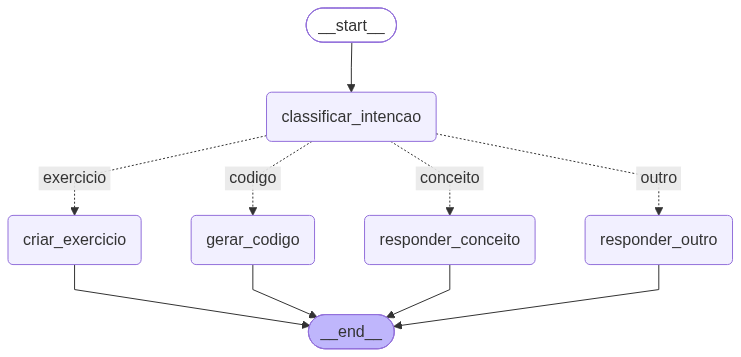

In [13]:
def rotear_por_intencao(
    state: EstadoRoteador,
) -> Literal["conceito", "codigo", "exercicio", "outro"]:
    """Devolve a categoria gravada pelo classificador."""
    return state["intencao"]


builder = StateGraph(EstadoRoteador)

builder.add_node("classificar_intencao", classificar_intencao)
builder.add_node("responder_conceito", responder_conceito)
builder.add_node("gerar_codigo", gerar_codigo)
builder.add_node("criar_exercicio", criar_exercicio)
builder.add_node("responder_outro", responder_outro)

builder.add_edge(START, "classificar_intencao")

builder.add_conditional_edges(
    "classificar_intencao",
    rotear_por_intencao,
    {
        "conceito": "responder_conceito",
        "codigo": "gerar_codigo",
        "exercicio": "criar_exercicio",
        "outro": "responder_outro",
    },
)

builder.add_edge("responder_conceito", END)
builder.add_edge("gerar_codigo", END)
builder.add_edge("criar_exercicio", END)
builder.add_edge("responder_outro", END)

graph = builder.compile()

display_graph(graph)

## 7.2 Caminho percorrido

A célula abaixo roda os quatro pedidos da seção 6 com `stream_mode="updates"` e imprime a sequência de nós de cada execução. O primeiro nó é o mesmo nos quatro casos, e o segundo depende da categoria devolvida pelo classificador.

In [14]:
for pedido in pedidos:
    nos = []

    for evento in graph.stream({"pedido": pedido}, stream_mode="updates"):
        nos.extend(evento)

    print(f"{' → '.join(nos):45} | {pedido}")

classificar_intencao → responder_conceito     | Explique o que é um reducer em LangGraph.
classificar_intencao → gerar_codigo           | Escreva um StateGraph com dois nós.
classificar_intencao → criar_exercicio        | Monte um exercício sobre add_messages.
classificar_intencao → responder_outro        | Quantos alunos tem a turma?


## 7.3 Resposta completa

A execução abaixo devolve o estado final de um dos pedidos, com a categoria, a justificativa e o texto produzido pelo nó especializado. O texto vem do nó que o mapa de `add_conditional_edges` associou à categoria.

In [15]:
resultado = graph.invoke({"pedido": "Monte um exercício sobre add_messages."})

print("Intenção:", resultado["intencao"])
print("Justificativa:", resultado["justificativa"])
print("-" * 60)
print(resultado["resposta"])

Intenção: exercicio
Justificativa: O aluno pede para montar um exercício, ou seja, solicitar prática sobre o tópico add_messages.
------------------------------------------------------------
**Exercício – Função `add_messages`**  
Implemente a função `add_messages(messages, new_msg)` que recebe uma lista `messages` e uma string `new_msg`. A função deve inserir `new_msg` ao final da lista apenas se ainda não existir uma mensagem idêntica (comparação sensível a maiúsculas/minúsculas). Caso a mensagem já esteja presente, a lista deve permanecer inalterada.  

**Critério de conclusão:** O código deve passar nos testes que verificam (1) inserção de mensagens únicas, (2) rejeição de duplicatas e (3) preservação da ordem original da lista.


## 7.4 Discussão

O padrão desta seção tem três etapas: classificar, rotear e executar um nó especializado. A alternativa é um prompt único que recebe o pedido, decide o tipo de resposta e a produz na mesma chamada.

A diferença aparece no que é possível inspecionar e alterar. A categoria escolhida fica em um campo do estado, e a saída de `stream` mostra qual nó rodou. Cada prompt de sistema cobre um tipo de pedido e é editado sem tocar nos outros. Uma categoria nova entra pelo esquema, por um nó e por uma entrada no mapa de `add_conditional_edges`.

O custo é o número de chamadas. O fluxo desta seção faz duas por pedido, uma para classificar e outra para responder, enquanto o prompt único faz uma.

---

# 8. Ciclo de revisão

Uma aresta condicional pode apontar para um nó anterior. Com isso, o grafo repete um trecho até um critério de parada. Esta seção monta três nós: um gera a resposta, um a avalia contra uma lista de critérios e um a reescreve a partir do feedback.

O avaliador usa saída estruturada, com um campo booleano no lugar do `Literal` da seção 6. A parada tem duas condições: a aprovação do avaliador ou o limite de tentativas.

Fluxo:

```text
START → gerar_resposta → avaliar_resposta
                              ├── aprovada ou limite atingido → END
                              └── caso contrário → revisar_resposta → avaliar_resposta
```

In [16]:
class AvaliacaoResposta(BaseModel):
    """Veredito do avaliador sobre a resposta do tutor."""

    aprovada: bool = Field(
        description="Verdadeiro quando a resposta atende aos três critérios."
    )
    feedback: str = Field(
        description="Uma frase indicando o ajuste pedido."
    )


class EstadoRevisao(TypedDict, total=False):
    pergunta: str
    resposta: str
    aprovada: bool
    feedback: str
    tentativas: int


avaliador = modelo.with_structured_output(AvaliacaoResposta, method="function_calling")

LIMITE_TENTATIVAS = 3

## 8.1 Campos opcionais do estado

O argumento `total=False` marca os campos do `TypedDict` como opcionais. A entrada do grafo traz apenas `pergunta`, e os demais campos são gravados durante a execução. Sem ele, a anotação exigiria as cinco chaves já na entrada.

O campo `tentativas` é escrito por dois nós: `gerar_resposta` grava `1` e `revisar_resposta` grava o valor anterior mais um. Sem reducer, a última escrita permanece no campo, e o critério de parada lê esse valor.

In [17]:
PAPEL_GERADOR = """Atue como tutor do curso de agentes com LLMs.
Responda à dúvida do aluno de forma direta."""

CRITERIOS = """Avalie a resposta do tutor por três critérios:

- nomeia o mecanismo do LangGraph envolvido;
- tem no máximo quatro frases;
- termina com uma linha iniciada por "Exemplo:".

A resposta é aprovada quando atende aos três.
Devolva o veredito preenchendo os campos aprovada e feedback."""


def gerar_resposta(state: EstadoRevisao) -> dict:
    """Produz a primeira versão da resposta e inicia a contagem de tentativas."""
    resposta = modelo.invoke(
        [SystemMessage(PAPEL_GERADOR), HumanMessage(state["pergunta"])]
    )

    return {"resposta": resposta.text, "tentativas": 1}


def avaliar_resposta(state: EstadoRevisao) -> dict:
    """Aplica os critérios à resposta corrente e devolve o veredito."""
    avaliacao = pedir_objeto(avaliador, [
        SystemMessage(CRITERIOS),
        HumanMessage(f"Pergunta:\n{state['pergunta']}\n\nResposta:\n{state['resposta']}"),
    ])

    return {"aprovada": avaliacao.aprovada, "feedback": avaliacao.feedback}


def revisar_resposta(state: EstadoRevisao) -> dict:
    """Reescreve a resposta a partir do feedback e incrementa a contagem."""
    resposta = modelo.invoke([
        SystemMessage(PAPEL_GERADOR + "\nReescreva a resposta atendendo ao feedback."),
        HumanMessage(
            f"Pergunta:\n{state['pergunta']}\n\n"
            f"Resposta atual:\n{state['resposta']}\n\n"
            f"Feedback:\n{state['feedback']}"
        ),
    ])

    return {"resposta": resposta.text, "tentativas": state["tentativas"] + 1}

## 8.2 Critério de parada

A função `decidir_continuidade` é a aresta condicional do ciclo. Ela lê dois campos do estado e devolve um dos dois destinos declarados no mapa. O limite de tentativas encerra a execução quando o avaliador não aprova a resposta em nenhuma das passagens.

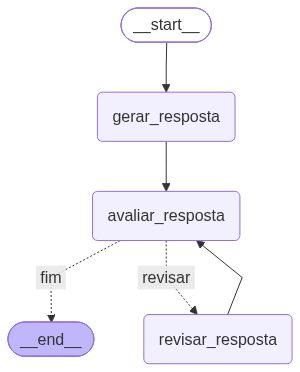

In [18]:
def decidir_continuidade(state: EstadoRevisao) -> Literal["revisar", "fim"]:
    """Encerra na aprovação do avaliador ou no limite de tentativas."""
    if state["aprovada"] or state["tentativas"] >= LIMITE_TENTATIVAS:
        return "fim"

    return "revisar"


builder = StateGraph(EstadoRevisao)

builder.add_node("gerar_resposta", gerar_resposta)
builder.add_node("avaliar_resposta", avaliar_resposta)
builder.add_node("revisar_resposta", revisar_resposta)

builder.add_edge(START, "gerar_resposta")
builder.add_edge("gerar_resposta", "avaliar_resposta")

builder.add_conditional_edges(
    "avaliar_resposta",
    decidir_continuidade,
    {"revisar": "revisar_resposta", "fim": END},
)

builder.add_edge("revisar_resposta", "avaliar_resposta")

graph = builder.compile()

display_graph(graph)

## 8.3 Execução do ciclo

A célula abaixo acompanha a execução com `stream_mode="updates"`. Os eventos do avaliador trazem o veredito e o feedback; os eventos de geração e revisão trazem o número da tentativa. A última resposta produzida é guardada e impressa ao final.

In [19]:
entrada = {"pergunta": "Por que um nó devolve atualização parcial do estado?"}
resposta_final = ""

for evento in graph.stream(entrada, stream_mode="updates"):
    for no, atualizacao in evento.items():
        if no == "avaliar_resposta":
            print(f"{no:18} | aprovada: {atualizacao['aprovada']} | {atualizacao['feedback']}")
        else:
            print(f"{no:18} | tentativa {atualizacao['tentativas']}")
            resposta_final = atualizacao["resposta"]

print("-" * 60)
print(resposta_final)

gerar_resposta     | tentativa 1
avaliar_resposta   | aprovada: False | A resposta não nomeia nenhum mecanismo do LangGraph, contém muito mais que quatro frases e não termina com uma linha iniciada por "Exemplo:".
revisar_resposta   | tentativa 2
avaliar_resposta   | aprovada: False | A resposta nomeia o mecanismo e tem quatro frases, mas a linha final não começa exatamente com "Exemplo:" (há markdown antes). Remova o negrito ou qualquer outro prefixo para que a última linha inicie com "Exemplo:".
revisar_resposta   | tentativa 3
avaliar_resposta   | aprovada: True | A resposta cumpre todos os requisitos.
------------------------------------------------------------
Em LangGraph, um nó devolve atualização parcial do estado porque o método `state.update(..., partial=True)` permite que ele envie apenas as chaves que realmente modificou. Assim, o nó não precisa aguardar que todo o grafo termine o processamento, reduzindo a latência e permitindo que outros nós continuem trabalhando de forma

## 8.4 Leitura da execução

1. `gerar_resposta` produz a primeira versão e grava `tentativas` igual a 1.
2. `avaliar_resposta` aplica os três critérios e grava `aprovada` e `feedback`.
3. `decidir_continuidade` lê os dois campos e devolve `revisar` ou `fim`.
4. `revisar_resposta` reescreve o texto com o feedback e incrementa `tentativas`.
5. A aresta `revisar_resposta → avaliar_resposta` fecha o ciclo.

O gerador recebe a dúvida do aluno e não recebe a lista de critérios. O avaliador aplica critérios que o gerador desconhece, e o feedback transporta essa informação de volta para a reescrita.

Na execução gravada, o avaliador reprovou a primeira versão nomeando os três critérios que faltavam, e aprovou a segunda. A parada veio da aprovação, com `tentativas` em 2, e não do limite. O grafo devolve a última resposta produzida com aprovação ou sem ela, porque `resposta` é um campo do estado e não depende do veredito.

## 8.5 Discussão

Este grafo tem o formato de um agente e não usa ferramentas externas. As três chamadas de modelo produzem texto e um veredito; a repetição, a condição de saída e a contagem de tentativas estão em código Python, no estado e nas arestas.

Isso define onde procurar quando o resultado sai errado. Um limite que dispara cedo demais aparece em `LIMITE_TENTATIVAS`, um critério mal escrito aparece em `CRITERIOS`, e a sequência de vereditos fica na saída de `stream`.

---

# 9. Exercícios de fixação

Os exercícios modificam exemplos já executados. Use as células vazias abaixo de cada enunciado.

## Exercício 1 — Turnos encadeados

Recompile o grafo de um nó da seção 2, com o estado `EstadoChat` e o nó `responder`, e execute quatro turnos reaproveitando o campo `messages` do estado devolvido a cada chamada. Imprima o número de mensagens ao fim de cada turno. No quarto turno, faça uma pergunta que só possa ser respondida com informação dada no primeiro, e verifique se a resposta a usa.

## Exercício 2 — Formato fixo no prompt

Recompile o grafo da seção 4, com o nó `tutor`, e execute a pergunta daquela seção. Altere `PROMPT_TUTOR` para exigir três partes na resposta, definição, exemplo em uma linha e erro comum, e execute a mesma pergunta de novo, sem recompilar. Reporte o número de frases de cada resposta e quais das três partes aparecem em cada uma.

## Exercício 3 — Categoria nova

Acrescente a categoria `comparacao` ao esquema `ClassificacaoIntencao` e à lista de `INSTRUCAO_CLASSIFICADOR`, e recrie `classificador` com `with_structured_output`, porque o objeto anterior guarda o esquema antigo. Recompile o grafo da seção 7 com o nó `comparar_ferramentas`, o valor novo no `Literal` de `rotear_por_intencao` e a entrada correspondente no mapa. Teste com o pedido `Compare LangChain e LangGraph`.

## Exercício 4 — Custo por rota

Recompile o grafo da seção 7 e rode os quatro pedidos da lista `pedidos` com `stream_mode="messages"`. Reporte, por nó, quantos pedaços com texto foram emitidos, e indique qual dos quatro prompts de papel produz a resposta mais longa.

## Exercício 5 — Histórico de avaliações

Importe `operator`, acrescente a `EstadoRevisao` o campo `historico_feedback` anotado com `operator.add`, e faça `avaliar_resposta` devolver `[feedback]` nesse campo. Recompile o grafo da seção 8 com o estado novo, porque `StateGraph` guarda a classe recebida na construção. Baixe `LIMITE_TENTATIVAS` para 2 e reporte quantos feedbacks o estado final guarda.

## Exercício 6 — Lugar da decisão

Sem executar código, indique onde cada decisão abaixo deve ficar, no prompt de um nó ou em uma aresta condicional, e justifique em duas frases: escolher o tom da resposta ao aluno; escolher entre responder o pedido e pedir mais contexto; escolher quantas vezes a resposta é reescrita. Considere, em cada caso, se a escolha muda o texto gerado ou o caminho da execução.

---

# 10. Resumo da aula

O notebook colocou chamadas de modelo dentro de nós de grafos, do caso de um nó até um ciclo com critério de parada. A cada seção, a saída do modelo passou a ocupar um papel diferente no estado: texto de resposta, categoria de rota e veredito de parada.

| Conceito | Ideia principal |
|---|---|
| Nó com chamada de modelo | A resposta do modelo vira a atualização parcial devolvida pelo nó. |
| `add_messages` | Reducer que concatena a lista de mensagens em vez de substituí-la. |
| Histórico | Reenviado a cada turno; o estado o transporta entre execuções. |
| Prompt de sistema | Montado pelo nó na hora da chamada, sem entrar no campo `messages`. |
| `stream_mode="updates"` | Um evento por nó executado, com o dicionário que ele devolveu. |
| `stream_mode="messages"` | Um evento por pedaço gerado, com o nó de origem nos metadados. |
| `with_structured_output` | Devolve um objeto validado pelo esquema em vez de uma `AIMessage`. |
| `Literal` no esquema | Restringe o campo aos valores aceitos pela aresta condicional. |
| `add_conditional_edges` | Liga o valor devolvido pela função de rota ao nome do nó de destino. |
| Nó especializado | Um prompt de sistema por tipo de pedido, editável isoladamente. |
| Aresta de volta | Aponta para um nó anterior e forma o ciclo de revisão. |
| Critério de parada | Condição em código que lê o estado e encerra a repetição. |

## 10.1 Checklist de compreensão

Questões de verificação:

1. O que aconteceria com o histórico se o campo `messages` não tivesse o reducer `add_messages`?
2. Por que a `SystemMessage` montada dentro do nó não aparece no estado final?
3. Que informação o modo `updates` traz que o retorno de `invoke` não traz?
4. Qual é a diferença entre o que `stream_mode="messages"` e `stream_mode="updates"` contam?
5. Por que o campo de rota precisa de um conjunto fechado de valores?
6. Em que ponto da execução aparece o erro quando o modelo devolve um valor fora do `Literal`?
7. Quantas chamadas de modelo o grafo da seção 7 faz por pedido, e onde está a segunda?
8. Quais são as duas condições que encerram o ciclo da seção 8?

## 10.2 Próximos passos

- Ferramentas chamadas pelo modelo, em que o nó executa uma função e devolve o resultado ao modelo na mesma execução;
- persistência por `thread_id`, que guarda o estado entre execuções e dispensa reenviar o histórico à mão;
- redução do histórico por corte ou por sumarização, quando a conversa passa da janela de contexto;
- avaliação de grafos, com um conjunto de entradas e critérios aplicados às saídas de cada versão.

---

# 11. Referências

- LangGraph, Graph API: https://docs.langchain.com/oss/python/langgraph/graph-api
- LangGraph, streaming: https://docs.langchain.com/oss/python/langgraph/streaming
- LangChain, saída estruturada: https://docs.langchain.com/oss/python/langchain/structured-output
- Referência de API, `StateGraph`: https://reference.langchain.com/python/langgraph/graph/state/StateGraph
- Referência de API, `add_messages`: https://reference.langchain.com/python/langgraph/graph/message/add_messages
- Referência de API, `ChatOllama`: https://reference.langchain.com/python/langchain-ollama/chat_models/ChatOllama
- Referência de API, `ChatGoogleGenerativeAI`: https://reference.langchain.com/python/langchain-google-genai/chat_models/ChatGoogleGenerativeAI
- Ollama, documentação: https://docs.ollama.com
- Gemini, mudanças de parâmetros nos modelos recentes: https://ai.google.dev/gemini-api/docs/generate-content/latest-model#api-changes-and-parameter-updates